# Single-Season Water & Energy Balance Diagnostic

Compares a **monoculture** maize season with an **evergreen deep-rooted tree-crop** season
(the primary agroforestry case of interest). Uses a fixed random seed for reproducibility.

**Purpose:** Verify that all model fluxes (supply-side and demand-side) are behaving correctly.

**System parameters:**
- Soil: loam (Krell 2021 Table 1); Zr_crop = 400 mm
- Tree: Zr = 1500 mm, T_MAX = 2.0 mm/day, canopy_cover = 0.2, leaf_fraction = 1.0
- Shade: k = 0.35 (Caylor et al. 2005); applied to both E and T_crop

In [1]:
import sys, os, nbformat
from IPython import get_ipython

# Navigate to repo root regardless of where the kernel started
if not os.path.exists('tree.ipynb'):
    os.chdir('..')
sys.path.insert(0, os.getcwd())

# Execute tree.ipynb cells directly (works in IDE and nbconvert)
_ip = get_ipython()
_nb = nbformat.read('tree.ipynb', as_version=4)
for _cell in _nb.cells:
    if _cell.cell_type == 'code':
        _ip.run_cell(_cell.source)

import warnings; warnings.filterwarnings('ignore')
os.makedirs('output/0317_figs', exist_ok=True)

/Users/cellaschnabel/miniforge3/envs/maize-Toff/lib/python3.10/site-packages/proplot/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


In [2]:
# Monthly-calibrated bimodal climate (CETRAD OL JOGI FARM, 1967-1999).
# Both systems use an identical rainfall realization for direct comparison.
CLIMATE_KWARGS = dict(
    station='OL JOGI FARM',
    data_file='data/CETRAD/CETRAD_rainfall.csv',
    interval='month'
)

np.random.seed(42)
climate = Climate(**CLIMATE_KWARGS)
crop_m, out_m = run_one_season(CropModel, Soil, Crop, climate, texture='loam', lgp=180)

TREE_PARAMS = dict(Zr=1500, T_MAX=2.0, sw_MPa=-4.0, s_star_MPa=-0.1,
                   kc=1.0, canopy_cover=0.2, leaf_fraction=1.0)
np.random.seed(42)
climate2 = Climate(**CLIMATE_KWARGS)
# n_spinup=5, t_before_spinup=178: each spin-up season covers the full annual
# cycle (DOY 287 -> DOY 287), capturing the short rains (Oct-Dec) deep
# percolation window that the original 60-day pre-season missed.
crop_t, out_t = run_one_season(TreeCropModel, Soil, Crop, climate2,
                               texture='loam', lgp=180, tree_params=TREE_PARAMS,
                               n_spinup=5, t_before_spinup=178)

cs_start = int((out_m['dos'] > 0).idxmax())
cs_end   = cs_start + 180
sf       = shade_factor(TREE_PARAMS.get('LAI_max', 2.0), TREE_PARAMS['canopy_cover'])

s_deep_0 = out_t['s_deep'].iloc[0]
has_deep  = 'YES' if s_deep_0 > 0.290 else 'NO -- s_deep < sw_tree all season'
print(f'Simulation length : {len(out_m)} days')
print(f'Crop season       : days {cs_start}-{cs_end}')
print(f'Seasonal rainfall : {out_m.R.sum():.1f} mm')
print(f'Shade factor (sf) : {sf:.3f}')
print(f's_deep[0]         : {s_deep_0:.4f}  (equilibrated via spinup)')
print(f'sw_tree           : ~0.290 (loam at sw_MPa=-4.0 MPa)')
print(f'Tree deep access  : {has_deep}')

Laikipia station data was inputted.


Laikipia station data was inputted.
Simulation length : 247 days
Crop season       : days 60-240
Seasonal rainfall : 512.0 mm
Shade factor (sf) : 0.899
s_deep[0]         : 0.2901  (equilibrated via spinup)
sw_tree           : ~0.290 (loam at sw_MPa=-4.0 MPa)
Tree deep access  : YES


In [3]:
import pandas as pd

def row(label, m, t):
    d = t - m
    p = d / m * 100 if m != 0 else float('nan')
    return {'Flux': label, 'Mono (mm)': f'{m:7.1f}', 'TreeCrop (mm)': f'{t:7.1f}',
            'Delta (mm)': f'{d:+7.1f}', 'Delta (%)': f'{p:+6.1f}' if p == p else '     -'}
def hdr(lbl):
    return {'Flux': lbl, 'Mono (mm)': '', 'TreeCrop (mm)': '', 'Delta (mm)': '', 'Delta (%)': ''}

R    = out_m['R'].sum()
I_m  = out_m['I'].sum();          I_t  = out_t['I'].sum()
E_m  = out_m['E'].sum();          E_t  = out_t['E'].sum()
T_m  = out_m['T'].sum();          T_t  = out_t['T_crop'].sum()  # CropModel: 'T', TreeCrop: 'T_crop'
L_m  = out_m['L'].sum();          L_t  = out_t['L'].sum()
Q_t  = out_t['Q'].sum()           # only in TreeCropModel output
HR   = out_t['HR'].sum()
Tts  = out_t['T_tree_top'].sum(); Ttd  = out_t['T_tree_deep'].sum()
Ttt  = out_t['T_tree'].sum()

soil_ref = Soil('loam')
nZr_top  = soil_ref.n * 400
nZr_deep = soil_ref.n * 1100
dS_m = nZr_top  * (out_m['s'].iloc[-1]       - out_m['s'].iloc[0])
dS_t = (nZr_top  * (out_t['s_top'].iloc[-1]  - out_t['s_top'].iloc[0]) +
        nZr_deep * (out_t['s_deep'].iloc[-1] - out_t['s_deep'].iloc[0]))

# Balance check: mono = R - I - E - T - L - dS (Q not in CropModel output)
res_m = R - I_m - E_m - T_m - L_m - dS_m
res_t = R - I_t - Q_t - E_t - T_t - Ttt - L_t + HR - dS_t

_, dyn_m, yld_m, _ = season_metrics(crop_m, out_m, 180)
_, dyn_t, yld_t, _ = season_metrics(crop_t, out_t, 180, sf=sf)

table = [
    hdr('--- INPUTS ---'),
    row('Rainfall (R)',              R,     R),
    row('Interception (I)',          I_m,   I_t),
    row('Net rainfall (R-I)',        R-I_m, R-I_t),
    hdr('--- SOIL / CROP LOSSES ---'),
    {'Flux': 'Runoff (Q)',           'Mono (mm)': '      -', 'TreeCrop (mm)': f'{Q_t:7.1f}', 'Delta (mm)': '', 'Delta (%)': ''},
    row('Soil evaporation (E)',      E_m,  E_t),
    row('Crop transpiration (T)',    T_m,  T_t),
    row('Leakage / drainage (L)',    L_m,  L_t),
    hdr('--- TREE-ONLY FLUXES ---'),
    {'Flux': 'Tree T shallow (competition)', 'Mono (mm)': '      -', 'TreeCrop (mm)': f'{Tts:7.1f}', 'Delta (mm)': '', 'Delta (%)': ''},
    {'Flux': 'Tree T deep',                  'Mono (mm)': '      -', 'TreeCrop (mm)': f'{Ttd:7.1f}', 'Delta (mm)': '', 'Delta (%)': ''},
    {'Flux': 'Tree T total',                 'Mono (mm)': '      -', 'TreeCrop (mm)': f'{Ttt:7.1f}', 'Delta (mm)': '', 'Delta (%)': ''},
    {'Flux': 'HR (lift to top layer)',        'Mono (mm)': '      -', 'TreeCrop (mm)': f'{HR:7.1f}',  'Delta (mm)': '', 'Delta (%)': ''},
    hdr('--- BALANCE CHECK ---'),
    {'Flux': 'Delta storage (dS)', 'Mono (mm)': f'{dS_m:+7.1f}', 'TreeCrop (mm)': f'{dS_t:+7.1f}', 'Delta (mm)': '', 'Delta (%)': ''},
    {'Flux': 'Residual (-> 0)',    'Mono (mm)': f'{res_m:+7.2f}', 'TreeCrop (mm)': f'{res_t:+7.2f}', 'Delta (mm)': '', 'Delta (%)': ''},
    hdr('--- CROP OUTCOME ---'),
    row('Dynamic stress (theta)',    dyn_m, dyn_t),
    row('Yield (kg/ha)',             yld_m, yld_t),
    {'Flux': 'Shade factor (sf)', 'Mono (mm)': '  1.000', 'TreeCrop (mm)': f'{sf:7.3f}',
     'Delta (mm)': f'{sf-1:+7.3f}', 'Delta (%)': f'{(sf-1)*100:+6.1f}'},
]

print(pd.DataFrame(table).to_string(index=False))


                        Flux Mono (mm) TreeCrop (mm) Delta (mm) Delta (%)
              --- INPUTS ---                                             
                Rainfall (R)     512.0         512.0       +0.0      +0.0
            Interception (I)      72.6          80.3       +7.7     +10.5
          Net rainfall (R-I)     439.4         431.7       -7.7      -1.7
  --- SOIL / CROP LOSSES ---                                             
                  Runoff (Q)         -           0.0                     
        Soil evaporation (E)     136.5         124.4      -12.1      -8.9
      Crop transpiration (T)     283.8         249.1      -34.7     -12.2
      Leakage / drainage (L)       0.1           0.0       -0.1    -100.0
    --- TREE-ONLY FLUXES ---                                             
Tree T shallow (competition)         -          59.1                     
                 Tree T deep         -           0.0                     
                Tree T total         -

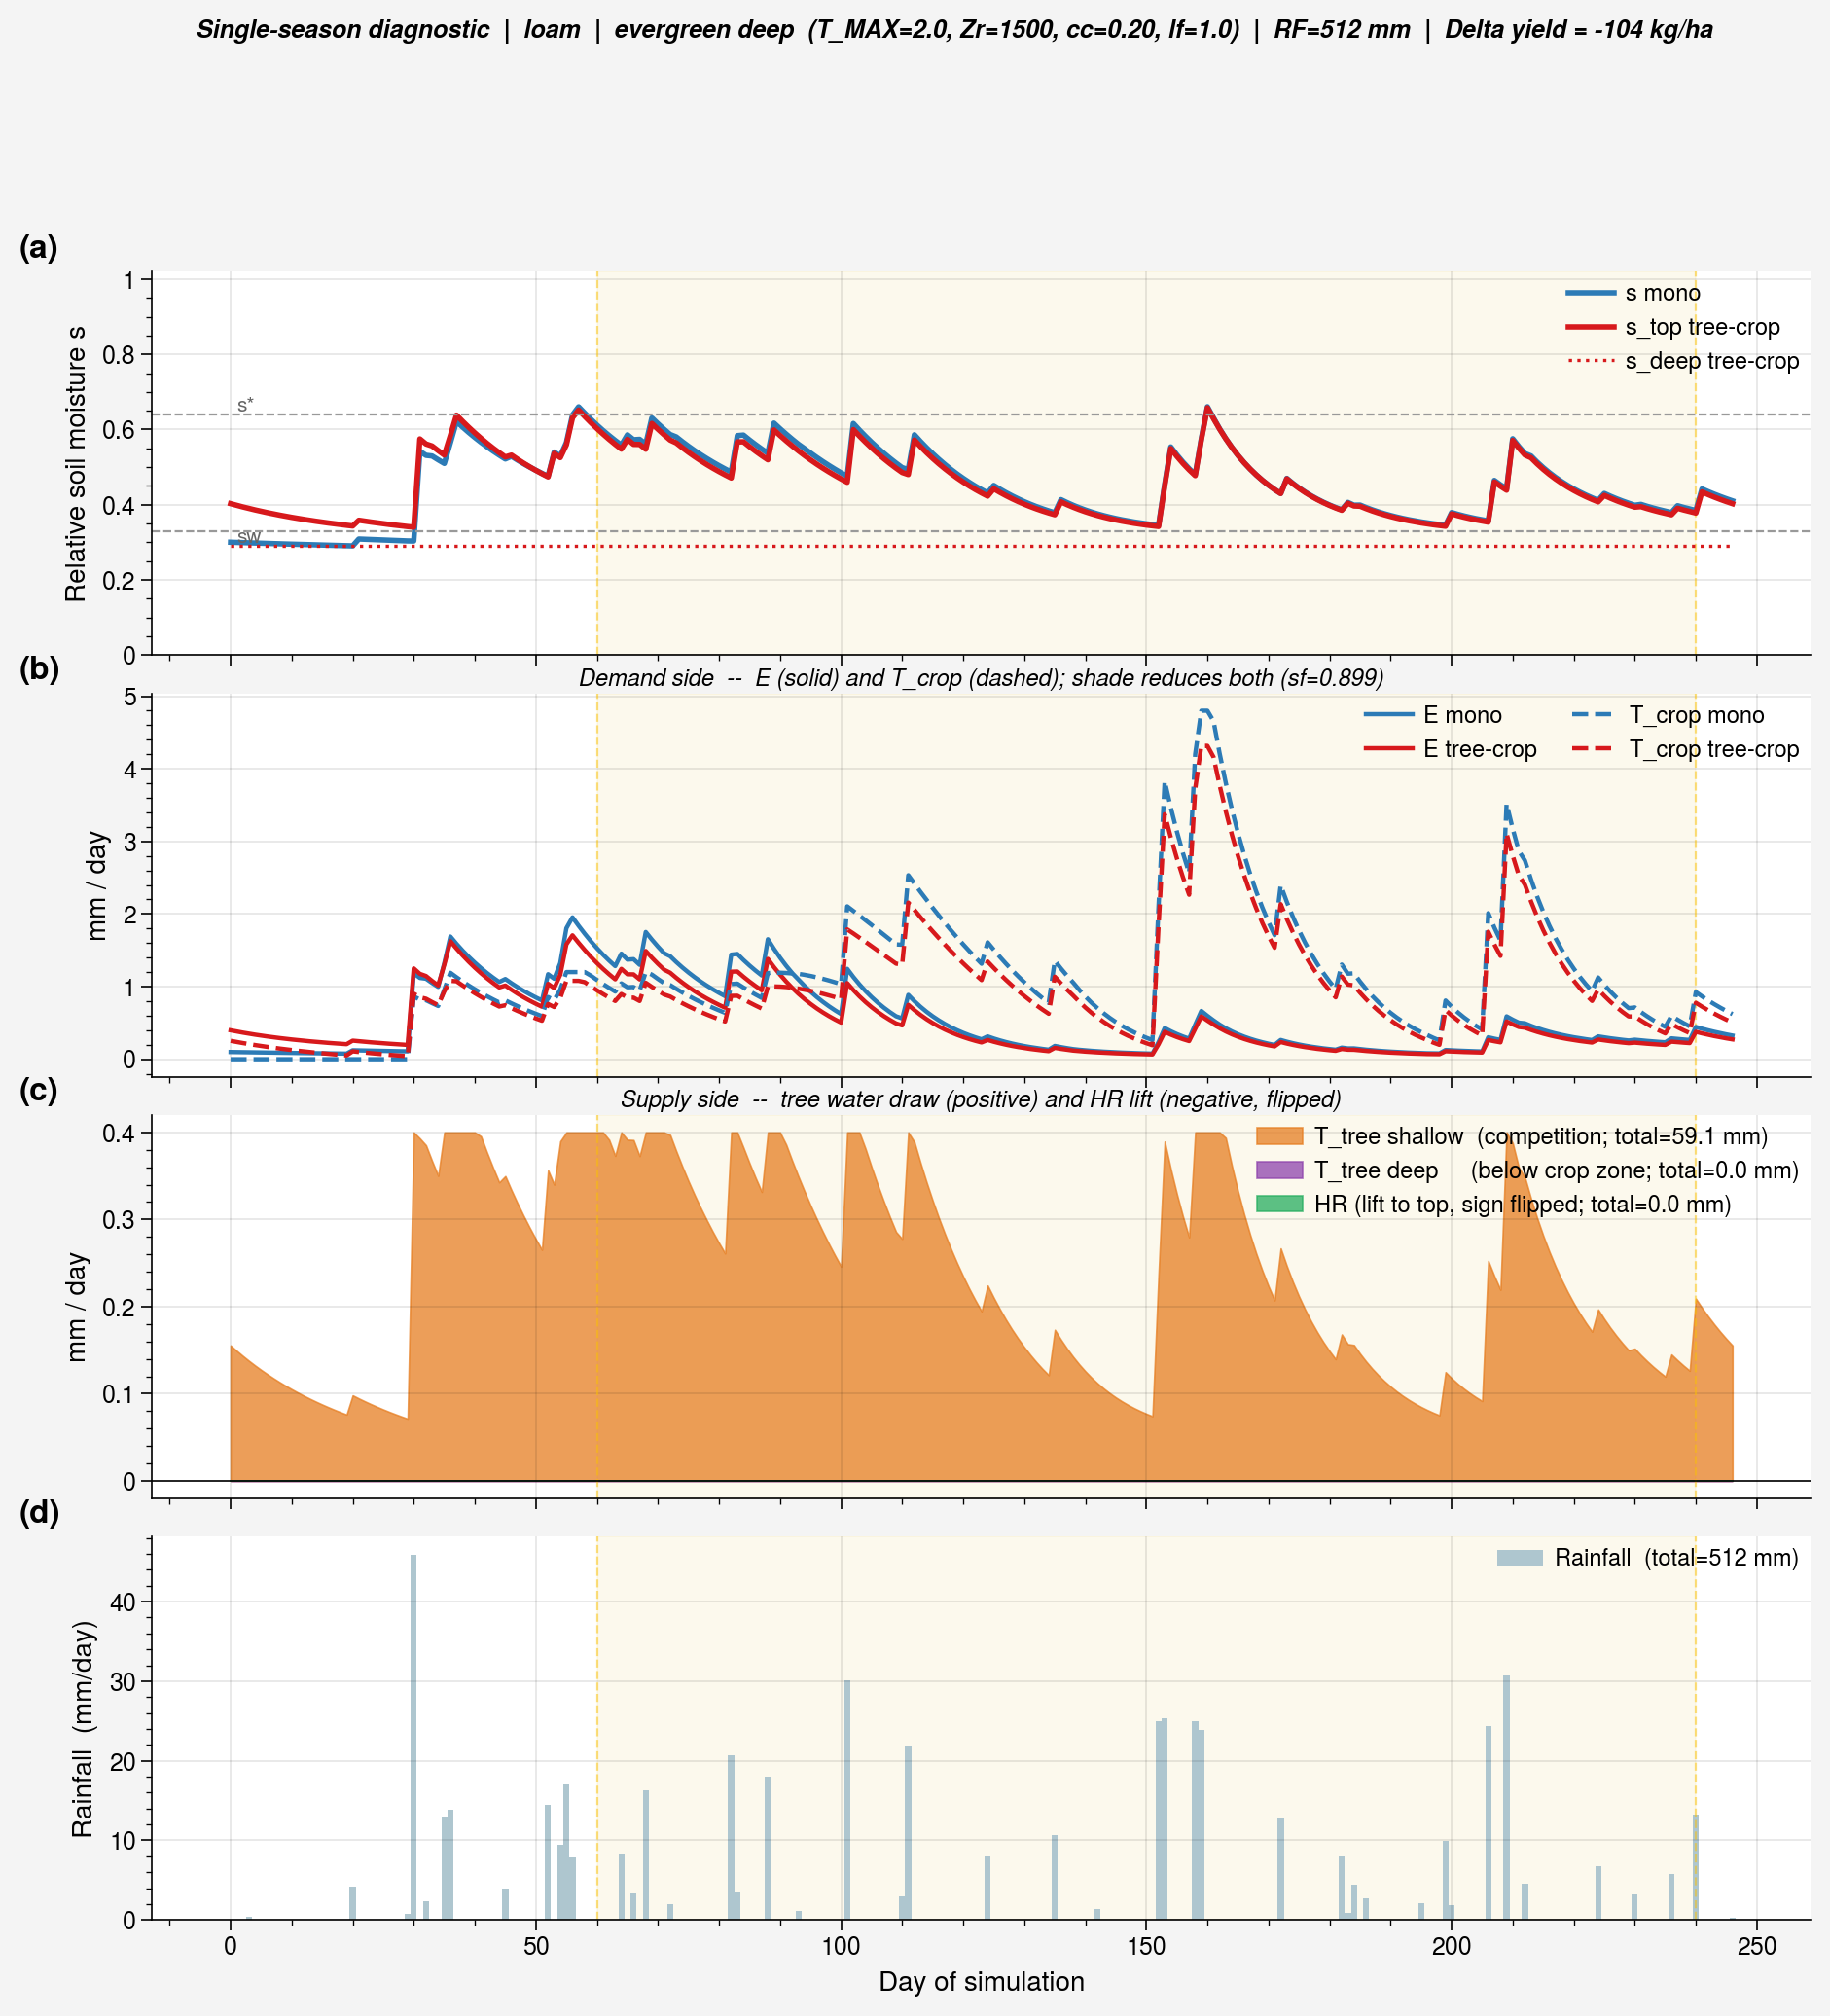

Saved -> output/0317_figs/single_season_diagnostic.png


In [4]:
days    = np.arange(len(out_m))
C_MONO  = '#2c7bb6'
C_TREE  = '#d7191c'
C_RAIN  = '#aec6cf'
C_HR    = '#27ae60'
C_DEEP  = '#8e44ad'
C_COMP  = '#e67e22'

# Convert to numpy arrays for matplotlib compatibility
R_arr        = out_m['R'].values
s_m          = out_m['s'].values
s_top        = out_t['s_top'].values
s_deep       = out_t['s_deep'].values
E_m_arr      = out_m['E'].values
E_t_arr      = out_t['E'].values
T_m_arr      = out_m['T'].values
T_t_arr      = out_t['T_crop'].values
Ttt_arr      = out_t['T_tree_top'].values
Ttd_arr      = out_t['T_tree_deep'].values
HR_arr       = out_t['HR'].values

fig, axes = plt.subplots(4, 1, figsize=(11, 11), sharex=True)
fig.subplots_adjust(hspace=0.10)

def mark_season(ax):
    ax.axvspan(cs_start, cs_end, color='gold', alpha=0.07, zorder=0)
    for x in [cs_start, cs_end]:
        ax.axvline(x, color='goldenrod', lw=0.8, ls='--', alpha=0.5)

soil_ref = Soil('loam'); crop_ref = Crop(soil=soil_ref)

# (a) soil moisture
ax = axes[0]; mark_season(ax)
ax.plot(days, s_m,    color=C_MONO, lw=2.0, label='s mono')
ax.plot(days, s_top,  color=C_TREE, lw=2.0, label='s_top tree-crop')
ax.plot(days, s_deep, color=C_TREE, lw=1.2, ls=':', label='s_deep tree-crop')
ax.axhline(crop_ref.sw,     color='#999', lw=0.8, ls='--')
ax.axhline(crop_ref.s_star, color='#999', lw=0.8, ls='--')
ax.text(1, crop_ref.sw - 0.03,     'sw', fontsize=7.5, color='#666')
ax.text(1, crop_ref.s_star + 0.01, 's*', fontsize=7.5, color='#666')
ax.set_ylabel('Relative soil moisture s', fontsize=10)
ax.set_ylim(0, 1.02); ax.legend(loc='upper right', fontsize=8.5)
despine(ax); pub_label(ax, '(a)')

# (b) E and T_crop — demand side
ax = axes[1]; mark_season(ax)
ax.plot(days, E_m_arr, color=C_MONO, lw=1.6, ls='-',  label='E mono')
ax.plot(days, E_t_arr, color=C_TREE, lw=1.6, ls='-',  label='E tree-crop')
ax.plot(days, T_m_arr, color=C_MONO, lw=1.6, ls='--', label='T_crop mono')
ax.plot(days, T_t_arr, color=C_TREE, lw=1.6, ls='--', label='T_crop tree-crop')
ax.set_ylabel('mm / day', fontsize=10)
ax.legend(loc='upper right', fontsize=8.5, ncol=2)
ax.set_title('Demand side  --  E (solid) and T_crop (dashed); shade reduces both (sf={:.3f})'.format(sf),
             fontsize=8.5, pad=3, style='italic')
despine(ax); pub_label(ax, '(b)')

# (c) tree water use + HR — supply side
ax = axes[2]; mark_season(ax)
ax.fill_between(days, Ttt_arr, 0, color=C_COMP, alpha=0.75,
                label=f'T_tree shallow  (competition; total={Tts:.1f} mm)')
ax.fill_between(days, Ttd_arr, 0, color=C_DEEP, alpha=0.75,
                label=f'T_tree deep     (below crop zone; total={Ttd:.1f} mm)')
ax.fill_between(days, -HR_arr, 0, color=C_HR,   alpha=0.75,
                label=f'HR (lift to top, sign flipped; total={HR:.1f} mm)')
ax.axhline(0, color='k', lw=0.6)
ax.set_ylabel('mm / day', fontsize=10)
ax.legend(loc='upper right', fontsize=8.5)
ax.set_title('Supply side  --  tree water draw (positive) and HR lift (negative, flipped)',
             fontsize=8.5, pad=3, style='italic')
despine(ax); pub_label(ax, '(c)')

# (d) seasonal rainfall
ax = axes[3]; mark_season(ax)
ax.bar(days, R_arr, color=C_RAIN, width=1.0, label=f'Rainfall  (total={R_arr.sum():.0f} mm)')
ax.set_ylabel('Rainfall  (mm/day)', fontsize=10)
ax.set_xlabel('Day of simulation', fontsize=10)
ax.legend(loc='upper right', fontsize=8.5)
despine(ax); pub_label(ax, '(d)')

fig.suptitle(
    f'Single-season diagnostic  |  loam  |  evergreen deep  '
    f'(T_MAX={TREE_PARAMS["T_MAX"]:.1f}, Zr=1500, cc=0.20, lf=1.0)  |  '
    f'RF={out_m.R.sum():.0f} mm  |  '
    f'Delta yield = {yld_t - yld_m:+.0f} kg/ha',
    fontsize=9, style='italic', y=0.998
)

plt.savefig('output/0317_figs/single_season_diagnostic.png')
plt.show()
print('Saved -> output/0317_figs/single_season_diagnostic.png')

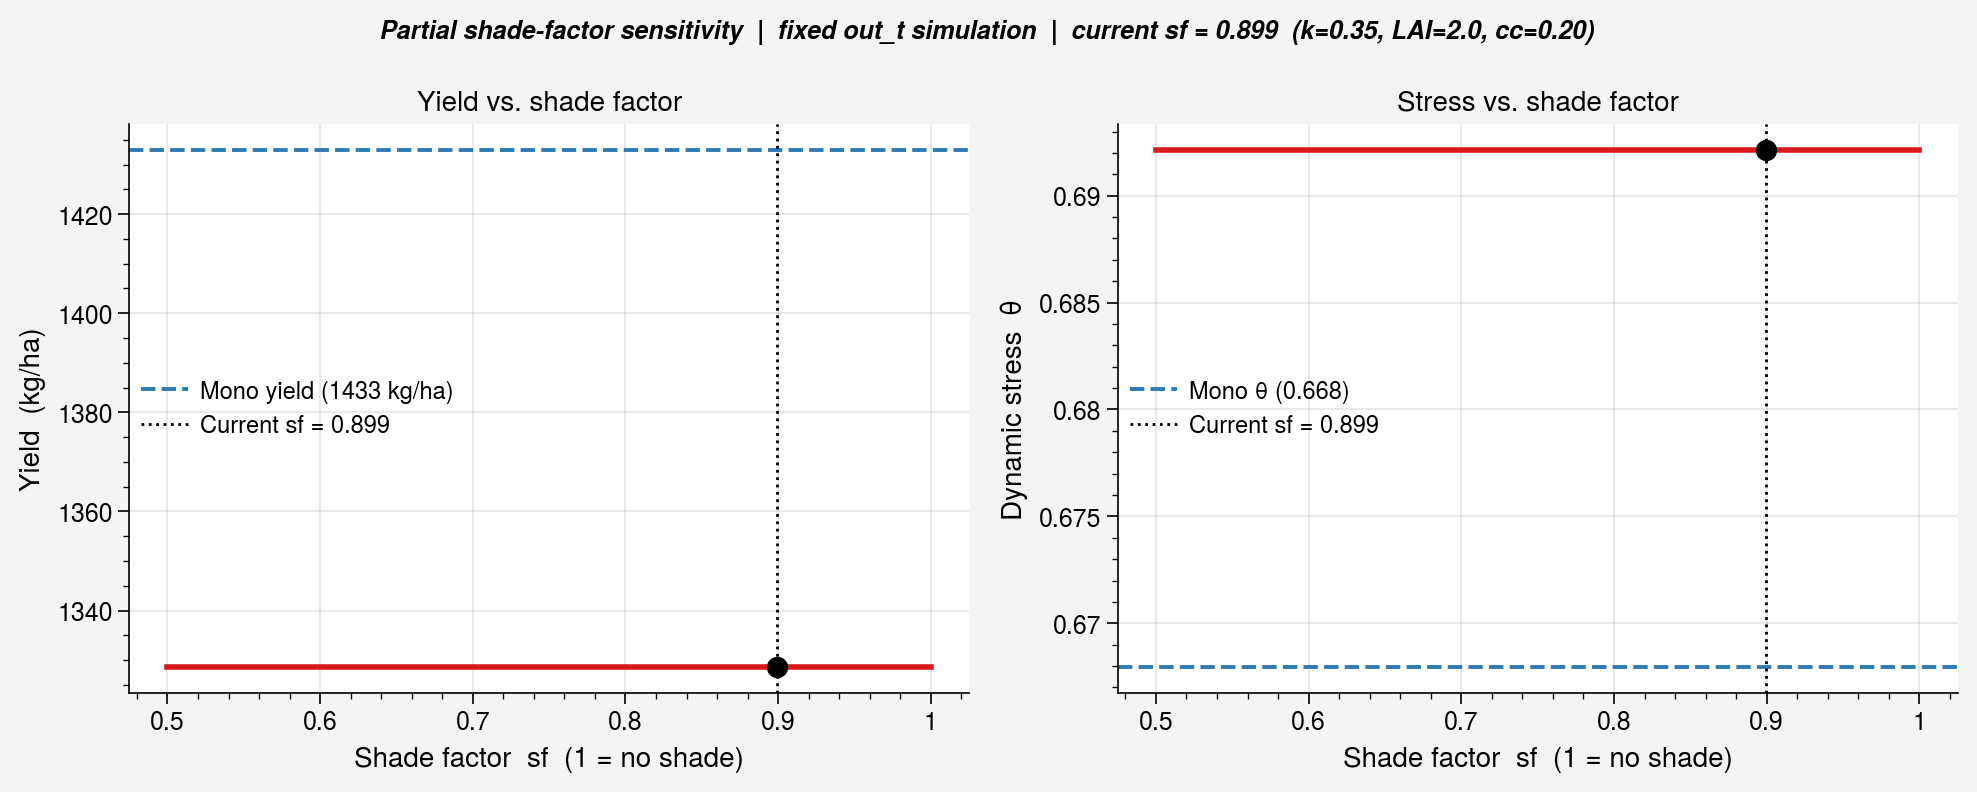

At current sf=0.899 :  yield = 1329 kg/ha,  θ = 0.692
At sf=1.00 (no shade)  :  yield = 1329 kg/ha,  θ = 0.692
At sf=0.50 (max shade) :  yield = 1329 kg/ha,  θ = 0.692

Yield swing (sf 0.5→1.0): +0 kg/ha
dy/d(sf) at current sf  : 0 kg/ha per unit sf


In [5]:
# ── THROWAWAY: sensitivity of yield to shade factor sf ──────────────────────────
# sf appears in season_metrics() as a scalar multiplier on T_crop and E PET.
# This sweep holds everything else fixed (same out_t simulation) and asks:
# "if shade were stronger/weaker, how much would yield move?"
# NOTE: this is a PARTIAL sensitivity — it only captures the demand-side
# pathway through season_metrics, not the feedback through daily soil moisture.

sf_vals = np.linspace(0.50, 1.00, 51)   # 1.0 = no shade; 0.5 = heavy shade

results = []
for sf_i in sf_vals:
    _, theta_i, yld_i, _ = season_metrics(crop_t, out_t, 180, sf=sf_i)
    results.append({'sf': sf_i, 'theta': theta_i, 'yield': yld_i})

res = pd.DataFrame(results)
sf_arr    = res['sf'].values
yld_arr   = res['yield'].values
theta_arr = res['theta'].values

# mono baseline for reference
_, theta_mono, yld_mono, _ = season_metrics(crop_m, out_m, 180)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.subplots_adjust(wspace=0.35)

ax = axes[0]
ax.plot(sf_arr, yld_arr, color=C_TREE, lw=2)
ax.axhline(yld_mono,  color=C_MONO, lw=1.4, ls='--', label=f'Mono yield ({yld_mono:.0f} kg/ha)')
ax.axvline(sf,        color='k',    lw=1.0, ls=':',  label=f'Current sf = {sf:.3f}')
ax.scatter([sf], [yld_t], color='k', zorder=5, s=50)
ax.set_xlabel('Shade factor  sf  (1 = no shade)', fontsize=10)
ax.set_ylabel('Yield  (kg/ha)', fontsize=10)
ax.set_title('Yield vs. shade factor', fontsize=10)
ax.legend(fontsize=8.5)
despine(ax)

ax = axes[1]
ax.plot(sf_arr, theta_arr, color=C_TREE, lw=2)
ax.axhline(theta_mono, color=C_MONO, lw=1.4, ls='--', label=f'Mono θ ({theta_mono:.3f})')
ax.axvline(sf,         color='k',    lw=1.0, ls=':',  label=f'Current sf = {sf:.3f}')
ax.scatter([sf], [dyn_t], color='k', zorder=5, s=50)
ax.set_xlabel('Shade factor  sf  (1 = no shade)', fontsize=10)
ax.set_ylabel('Dynamic stress  θ', fontsize=10)
ax.set_title('Stress vs. shade factor', fontsize=10)
ax.legend(fontsize=8.5)
despine(ax)

fig.suptitle(
    'Partial shade-factor sensitivity  |  fixed out_t simulation  |  '
    f'current sf = {sf:.3f}  (k=0.35, LAI=2.0, cc=0.20)',
    fontsize=9, style='italic'
)
plt.tight_layout()
plt.show()

# quick numerical summary
hi = res[res.sf >= 1.0].iloc[0]
print(f"At current sf={sf:.3f} :  yield = {yld_t:.0f} kg/ha,  θ = {dyn_t:.3f}")
print(f"At sf=1.00 (no shade)  :  yield = {hi['yield']:.0f} kg/ha,  θ = {hi['theta']:.3f}")
print(f"At sf=0.50 (max shade) :  yield = {res.iloc[0]['yield']:.0f} kg/ha,  θ = {res.iloc[0]['theta']:.3f}")
d_yld = hi['yield'] - res.iloc[0]['yield']
print(f"\nYield swing (sf 0.5→1.0): {d_yld:+.0f} kg/ha")
print(f"dy/d(sf) at current sf  : {np.gradient(yld_arr, sf_arr)[25]:.0f} kg/ha per unit sf")


---
## Simple 1-D sensitivity: ΔY vs each key parameter

Each sweep holds all other parameters fixed at the base archetype (Zr=1500, T_MAX=2.0, cc=0.20, lf=1.0).  
Paired simulations: same seed → same rainfall year for mono and tree-crop.  
`s_deep` initialised to `s0 = 0.3` (same as `s_top`) — no spinup.

In [6]:
# ── Compute all 4 sweeps ──────────────────────────────────────────────────────
N   = 100          # seasons per parameter value
S0  = 0.3          # initial soil moisture (both layers)
LGP = 180

BASE = dict(Zr=1500, T_MAX=2.0, sw_MPa=-4.0, s_star_MPa=-0.1,
            kc=1.0, canopy_cover=0.2, leaf_fraction=1.0)

def _make_climate(alpha=10.0, lam=0.25):
    c = Climate()
    c.alpha_r  = np.array([alpha] * 365)
    c.lambda_r = np.array([lam]   * 365)
    return c

def _dY(tree_params, climate_obj, seeds):
    """ΔY = Y_tree_crop − Y_mono for each seed. s_deep_0 = s0 (no spinup)."""
    sf_ = _tree_sf(tree_params)
    out = []
    for seed in seeds:
        np.random.seed(seed)
        climate_obj.rainfall = Climate.generate(climate_obj.alpha_r, climate_obj.lambda_r)

        s_m = Soil(texture='loam'); c_m = Crop(soil=s_m); c_m.lgp = LGP
        s_m.set_nZr(c_m)
        m_m = CropModel(crop=c_m, climate=climate_obj, soil=s_m)
        m_m.run(s0=S0)
        _, _, y_m, _ = season_metrics(c_m, m_m.output(), LGP)

        s_t = Soil(texture='loam'); c_t = Crop(soil=s_t); c_t.lgp = LGP
        tr_ = Tree(soil=s_t, **tree_params)
        m_t = TreeCropModel(crop=c_t, tree=tr_, climate=climate_obj, soil=s_t)
        m_t.run(s0=S0)   # s_deep_0 defaults to s0 when not passed
        _, _, y_t, _ = season_metrics(c_t, m_t.output(), LGP, sf=sf_)

        out.append(y_t - y_m)
    return np.array(out)

seeds = np.arange(N)

# 1. Mean seasonal rainfall (scale λ, keep α=10 mm fixed)
LAM_VALS = [0.25 * s for s in [0.3, 0.5, 0.7, 1.0, 1.3, 1.6, 2.0]]
RF_MEANS  = [10 * l * LGP for l in LAM_VALS]   # mm/season
dY_rf = []
for lam in LAM_VALS:
    dY_rf.append(_dY(BASE, _make_climate(lam=lam), seeds))

# 2. Rainfall regime (α vs λ at fixed total RF ≈ 450 mm/season)
REGIMES = [
    dict(label='Intense\n(α=20, λ=0.125)',  alpha=20.0, lam=0.125),
    dict(label='Baseline\n(α=10, λ=0.25)',  alpha=10.0, lam=0.250),
    dict(label='Frequent\n(α=5,  λ=0.5)',   alpha=5.0,  lam=0.500),
]
dY_reg = [_dY(BASE, _make_climate(r['alpha'], r['lam']), seeds) for r in REGIMES]

# 3. Canopy cover
c_base  = _make_climate()
CC_VALS = [0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]
dY_cc   = [_dY({**BASE, 'canopy_cover': cc}, c_base, seeds) for cc in CC_VALS]

# 4. Leaf fraction
LF_VALS = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
dY_lf   = [_dY({**BASE, 'leaf_fraction': lf}, c_base, seeds) for lf in LF_VALS]

print('Done.')

Done.


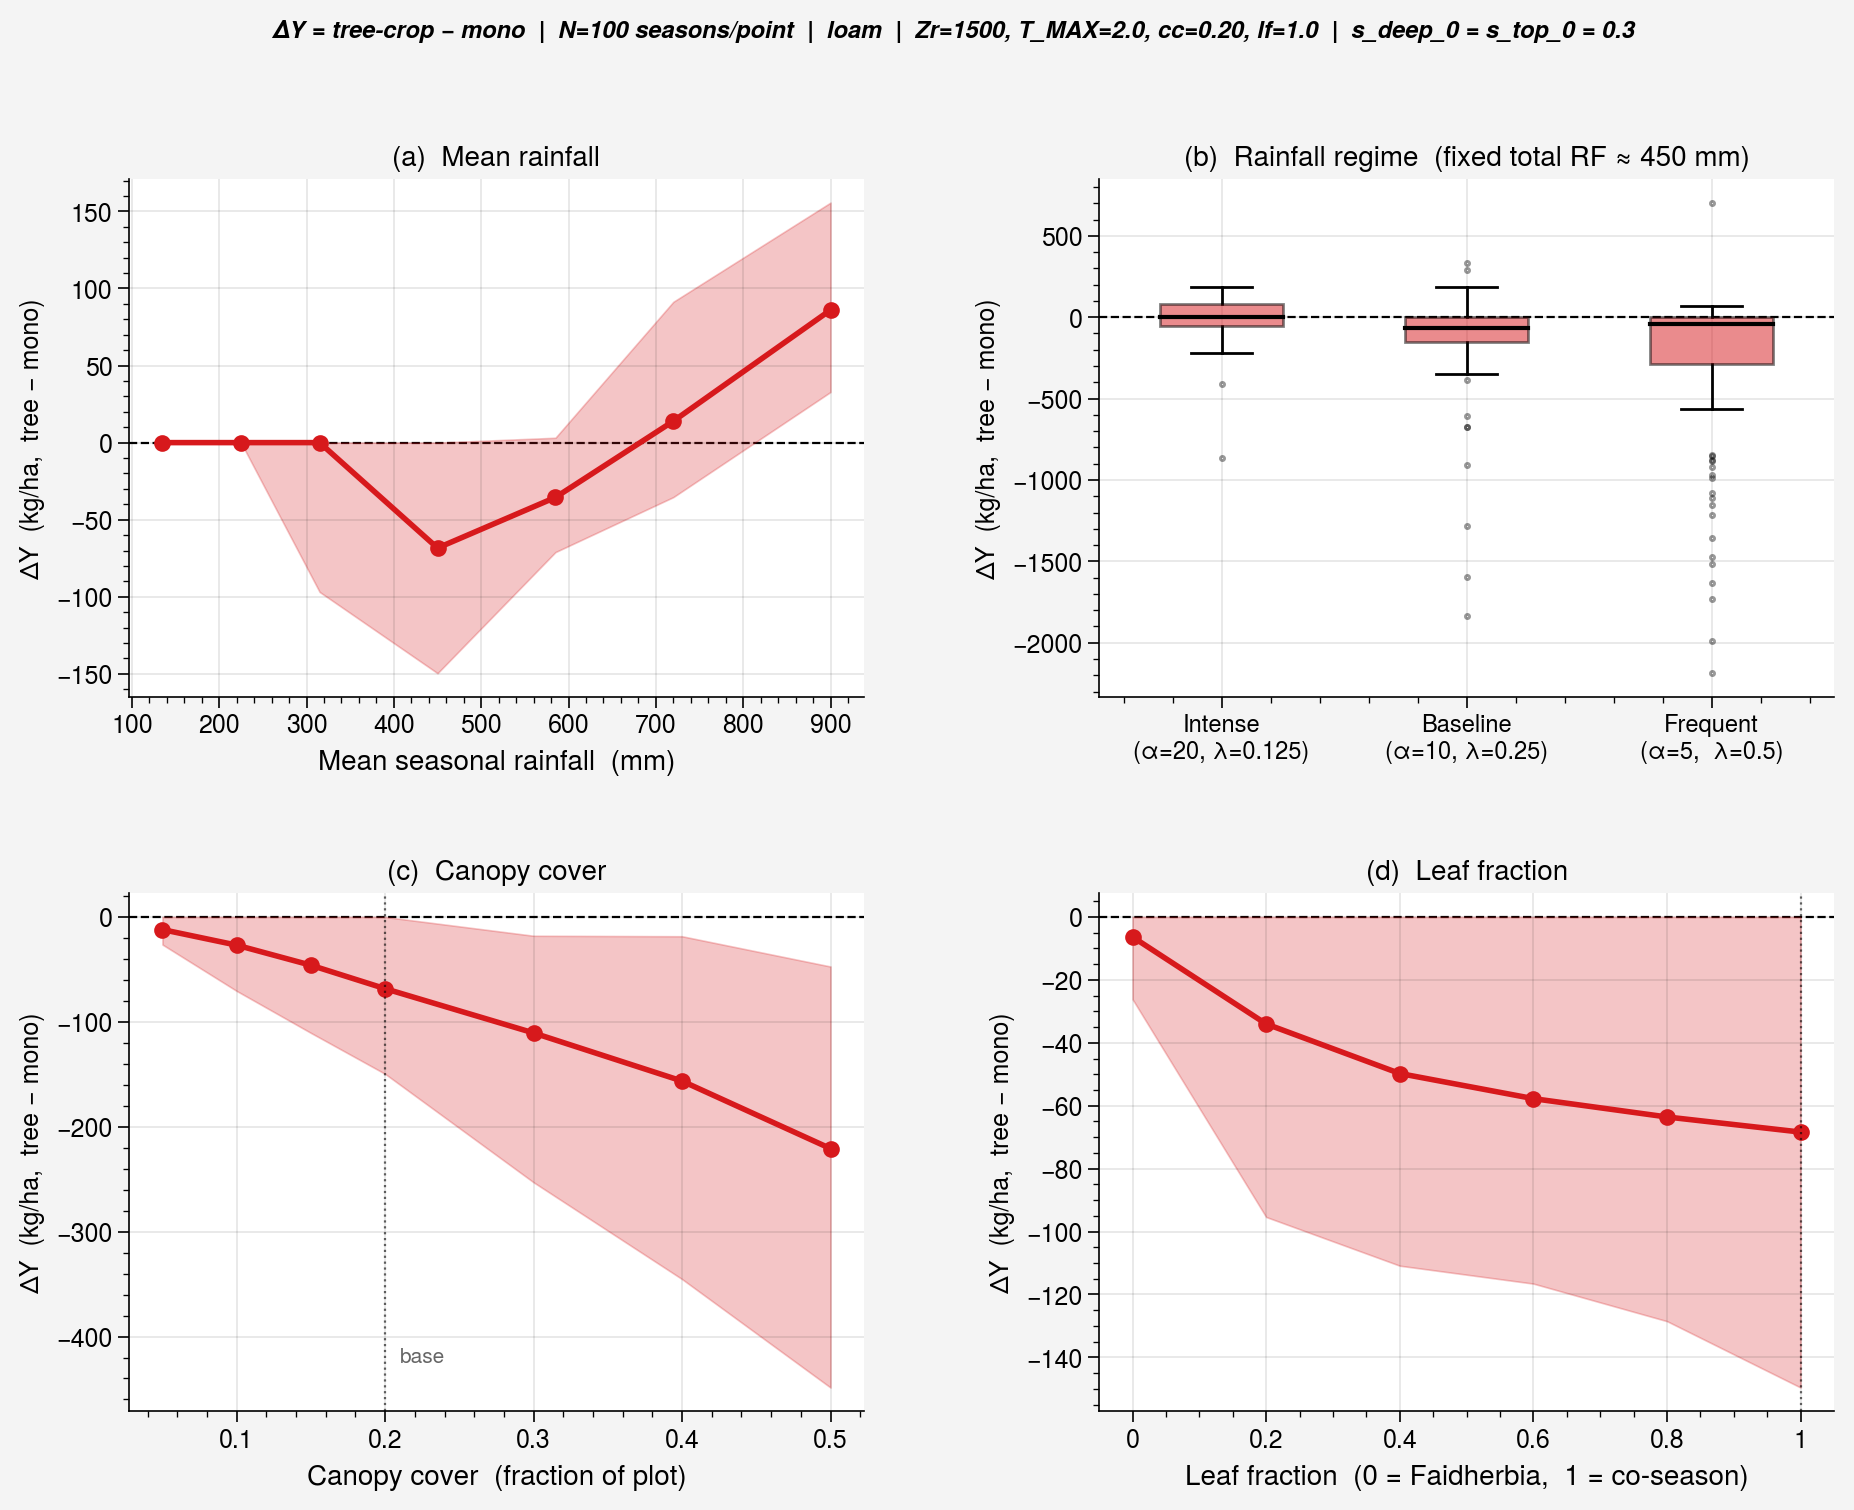

Saved → output/0317_figs/sensitivity_4panel.png


In [7]:
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
fig.subplots_adjust(hspace=0.38, wspace=0.32)

def _line(ax, x, dY_list, xlabel, xticklabels=None):
    med = np.array([np.median(d) for d in dY_list])
    q25 = np.array([np.percentile(d, 25) for d in dY_list])
    q75 = np.array([np.percentile(d, 75) for d in dY_list])
    ax.axhline(0, color='k', lw=0.8, ls='--', zorder=0)
    ax.fill_between(x, q25, q75, color=C_TREE, alpha=0.25)
    ax.plot(x, med, color=C_TREE, lw=2, marker='o', ms=5)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('ΔY  (kg/ha,  tree − mono)', fontsize=9)
    if xticklabels is not None:
        ax.set_xticks(x)
        ax.set_xticklabels(xticklabels, fontsize=8)
    despine(ax)

# (a) Mean seasonal rainfall
ax = axes[0, 0]
_line(ax, RF_MEANS, dY_rf, 'Mean seasonal rainfall  (mm)')
ax.set_title('(a)  Mean rainfall', fontsize=10)

# (b) Rainfall regime — box plot
ax = axes[0, 1]
ax.axhline(0, color='k', lw=0.8, ls='--', zorder=0)
positions = [1, 2, 3]
bp = ax.boxplot(dY_reg, positions=positions, widths=0.5,
                patch_artist=True, medianprops=dict(color='k', lw=1.5),
                boxprops=dict(facecolor=C_TREE, alpha=0.5),
                whiskerprops=dict(lw=1), capprops=dict(lw=1),
                flierprops=dict(marker='.', ms=3, alpha=0.4))
ax.set_xticks(positions)
ax.set_xticklabels([r['label'] for r in REGIMES], fontsize=8.5)
ax.set_ylabel('ΔY  (kg/ha,  tree − mono)', fontsize=9)
ax.set_title('(b)  Rainfall regime  (fixed total RF ≈ 450 mm)', fontsize=10)
despine(ax)

# (c) Canopy cover
ax = axes[1, 0]
_line(ax, CC_VALS, dY_cc, 'Canopy cover  (fraction of plot)')
ax.axvline(0.2, color='k', lw=0.8, ls=':', alpha=0.6)
ax.text(0.21, ax.get_ylim()[0] * 0.9, 'base', fontsize=7.5, color='#666')
ax.set_title('(c)  Canopy cover', fontsize=10)

# (d) Leaf fraction
ax = axes[1, 1]
_line(ax, LF_VALS, dY_lf, 'Leaf fraction  (0 = Faidherbia,  1 = co-season)')
ax.axvline(1.0, color='k', lw=0.8, ls=':', alpha=0.6)
ax.set_title('(d)  Leaf fraction', fontsize=10)
despine(ax)

fig.suptitle(
    f'ΔY = tree-crop − mono  |  N={N} seasons/point  |  '
    f'loam  |  Zr=1500, T_MAX=2.0, cc=0.20, lf=1.0  |  s_deep_0 = s_top_0 = {S0}',
    fontsize=8.5, style='italic'
)

plt.savefig('output/0317_figs/sensitivity_4panel.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → output/0317_figs/sensitivity_4panel.png')